In [16]:
import pandas as pd

df = pd.read_csv(
    "Online Frauds - Statewise.csv"
)

print(df.shape)

df.head(10)

(36, 11)


,State/UT,Frauds FY 19-20,Amount Involved (Cr) FY 19-20,Frauds FY 20-21,Amount Involved (Cr) FY 20-21,Frauds FY 21-22,Amount Involved (Cr) FY 21-22,Frauds FY 22-23,Amount Involved (Cr) FY 22-23,Frauds FY 23-24,Amount Involved (Cr) FY 23-24
0,Andaman & Nicobar Islands,1,0.01,0,0.00,0,0.00,1,0.01,6,0.16
1,Andhra Pradesh,23,0.97,23,1.08,26,0.83,59,4.28,444,16.30
2,Arunachal Pradesh,2,0.02,8,0.12,0,0.00,0,0.00,11,0.39
3,Assam,77,1.30,34,0.71,17,1.22,25,0.70,224,8.04
4,Bihar,34,0.55,38,0.65,54,2.09,67,2.28,405,11.66
5,Chandigarh,13,0.24,7,0.42,26,0.81,21,0.54,100,2.67
6,Chhattisgarh,14,0.23,7,0.14,21,4.52,36,4.66,192,6.47
7,Dadra and Nagar Haveli and Daman and Diu,0,0.00,3,0.07,5,0.12,4,0.09,15,0.49
8,Goa,4,0.05,7,0.19,8,0.42,13,0.39,50,1.16
9,Gujarat,51,2.87,131,6.27,146,5.14,237,9.87,1349,49.92


In [17]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

import numpy as np

# Encode state names
df["State/UT"] = LabelEncoder().fit_transform(
    df["State/UT"]
)

# Create label from latest fraud volume
threshold = df[
    "Frauds FY 23-24"
].median()

df["Risk_Label"] = (
    df["Frauds FY 23-24"] > threshold
).astype(int)

print(
    df[
        ["Frauds FY 23-24",
         "Risk_Label"]
    ].head()
)

# Features
X = df.drop(
    "Risk_Label",
    axis=1
)

# Target
y = df["Risk_Label"].values

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Use max 8 features
X_final = X_scaled[:,:8]

print(
    "Feature Shape:",
    X_final.shape
)

   Frauds FY 23-24  Risk_Label
0                6           0
1              444           1
2               11           0
3              224           1
4              405           1
Feature Shape: (36, 8)


In [18]:
import pennylane as qml

from pennylane import numpy as pnp

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

np.random.seed(42)

In [28]:
def indian_vqc(n_qubits):

    print("\n===================")

    print(
        "Running",
        n_qubits,
        "Qubits"
    )

    print("===================")


    dev=qml.device(
        "default.qubit",
        wires=n_qubits
    )


    @qml.qnode(dev)
    def circuit(x,params):

        # Feature encoding
        for i in range(n_qubits):

            qml.RY(
                x[i],
                wires=i
            )

        p=0

        depth=n_qubits//2

        for d in range(depth):

            # Trainable rotations
            for i in range(n_qubits):

                qml.RY(
                    params[p],
                    wires=i
                )

                p+=1

            # Entanglement
            for i in range(
                n_qubits-1
            ):

                qml.CNOT(
                    wires=[i,i+1]
                )

        return qml.expval(
            qml.PauliZ(0)
        )


    # Small dataset → use all rows
    X_train=X_final

    y_train=y


    # Parameters
    params=pnp.random.randn(
        (n_qubits//2)
        *n_qubits,
        requires_grad=True
    )


    # FIXED loss
    def loss(params):

        preds=[]

        for x in X_train:

            val=circuit(
                x[:n_qubits],
                params
            )

            preds.append(
                (val+1)/2
            )

        preds=pnp.array(
            preds,
            requires_grad=True
        )

        y_true=pnp.array(
            y_train
        )

        return pnp.mean(
            (preds-y_true)**2
        )


    # Optimizer
    opt=qml.AdamOptimizer(
        0.05
    )

    epochs=30

    loss_history=[]


    # Training
    for e in range(epochs):

        params=opt.step(
            loss,
            params
        )

        l=loss(params)

        loss_history.append(l)

        print(
            "Epoch",
            e,
            "Loss",
            l
        )


    # Loss Plot
    plt.plot(
        loss_history
    )

    plt.title(
        str(n_qubits)
        +" Qubit Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.grid()

    plt.show()


    # Circuit diagram
    print(
        qml.draw(circuit)(
            X_final[0][:n_qubits],
            params
        )
    )


    # Prediction
    scores=[]

    for x in X_final:

        scores.append(
            circuit(
                x[:n_qubits],
                params
            )
        )

    threshold=np.percentile(scores,55)

    # If needed later:
    # threshold=np.percentile(scores,55)

    y_pred=(
        np.array(scores)
        > threshold
    ).astype(int)


    acc=accuracy_score(
        y,
        y_pred
    )

    print(
        "Accuracy:",
        round(acc,4)
    )

    return acc


Running 4 Qubits
Epoch 0 Loss 0.38592223062779224
Epoch 1 Loss 0.3834164186090503
Epoch 2 Loss 0.3807212367883083
Epoch 3 Loss 0.3778239018762721
Epoch 4 Loss 0.37470802625778366
Epoch 5 Loss 0.37134651770954347
Epoch 6 Loss 0.3676899297245948
Epoch 7 Loss 0.36365300160313824
Epoch 8 Loss 0.3591096278250821
Epoch 9 Loss 0.3539112214368263
Epoch 10 Loss 0.34792908533646405
Epoch 11 Loss 0.34109618758592786
Epoch 12 Loss 0.333425868591811
Epoch 13 Loss 0.3250100353534831
Epoch 14 Loss 0.31600963854213293
Epoch 15 Loss 0.306643662968774
Epoch 16 Loss 0.29717564880298464
Epoch 17 Loss 0.28789364455451844
Epoch 18 Loss 0.279078791140277
Epoch 19 Loss 0.2709595933038102
Epoch 20 Loss 0.2636576859626387
Epoch 21 Loss 0.2571506434096874
Epoch 22 Loss 0.2512919509238795
Epoch 23 Loss 0.2458956569346218
Epoch 24 Loss 0.24082733331826212
Epoch 25 Loss 0.23604059046411774
Epoch 26 Loss 0.23156081435894174
Epoch 27 Loss 0.22745047816535224
Epoch 28 Loss 0.22377874668085818
Epoch 29 Loss 0.22060133

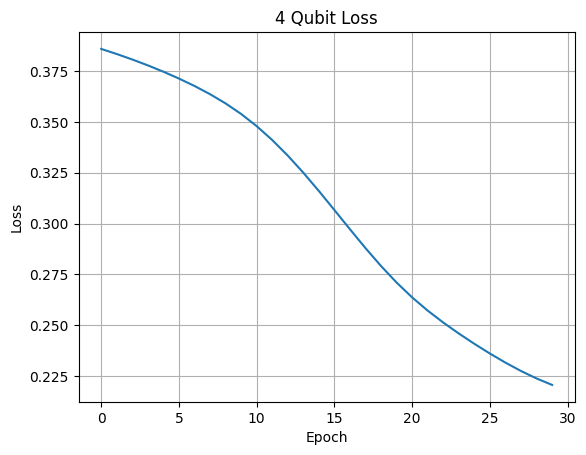

0: ──RY(-1.68)──RY(0.75)─╭●──RY(-1.59)───────────╭●───────────────┤  <Z>
1: ──RY(-0.47)──RY(0.36)─╰X─╭●──────────RY(1.56)─╰X─────────╭●────┤     
2: ──RY(-0.43)──RY(0.36)────╰X─────────╭●─────────RY(-2.62)─╰X─╭●─┤     
3: ──RY(-0.47)──RY(1.54)───────────────╰X─────────RY(0.82)─────╰X─┤     
Accuracy: 0.7222


In [29]:
acc4 = indian_vqc(4)


Running 6 Qubits
Epoch 0 Loss 0.26424065485376014
Epoch 1 Loss 0.24887499487031464
Epoch 2 Loss 0.23426703537716959
Epoch 3 Loss 0.22125226967488365
Epoch 4 Loss 0.2106819015286236
Epoch 5 Loss 0.20327682199833447
Epoch 6 Loss 0.1993872348808572
Epoch 7 Loss 0.19869384102170437
Epoch 8 Loss 0.20009823731236123
Epoch 9 Loss 0.20214410339664965
Epoch 10 Loss 0.2036870653754736
Epoch 11 Loss 0.20416609027821536
Epoch 12 Loss 0.20348590287602122
Epoch 13 Loss 0.20181998767104353
Epoch 14 Loss 0.19946531471276324
Epoch 15 Loss 0.1967545809288776
Epoch 16 Loss 0.1940035827913719
Epoch 17 Loss 0.1914755520268234
Epoch 18 Loss 0.1893556493215833
Epoch 19 Loss 0.18773760641738313
Epoch 20 Loss 0.18662603955181026
Epoch 21 Loss 0.18595359180366478
Epoch 22 Loss 0.18560683132248712
Epoch 23 Loss 0.18545307881959577
Epoch 24 Loss 0.18536290949764408
Epoch 25 Loss 0.18522721828452532
Epoch 26 Loss 0.18496977375100088
Epoch 27 Loss 0.18455510729941077
Epoch 28 Loss 0.18398994997637053
Epoch 29 Loss

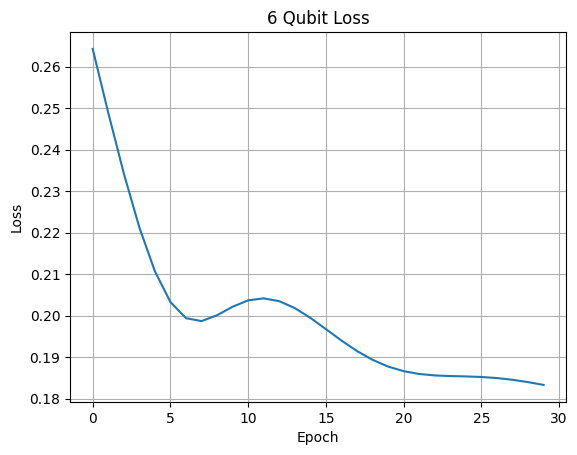

0: ──RY(-1.68)──RY(-1.47)─╭●──RY(1.00)────────────╭●──────────RY(1.25)───────────╭●──────── ···
1: ──RY(-0.47)──RY(-1.25)─╰X─╭●─────────RY(-1.16)─╰X─────────╭●─────────RY(0.36)─╰X──────── ···
2: ──RY(-0.43)──RY(0.03)─────╰X────────╭●──────────RY(-1.42)─╰X────────╭●─────────RY(-1.47) ···
3: ──RY(-0.47)──RY(0.96)───────────────╰X─────────╭●──────────RY(0.19)─╰X────────╭●──────── ···
4: ──RY(-0.49)──RY(1.79)──────────────────────────╰X─────────╭●─────────RY(0.14)─╰X──────── ···
5: ──RY(-0.42)──RY(0.58)─────────────────────────────────────╰X─────────RY(0.61)─────────── ···

0: ··· ────────────────────────────┤  <Z>
1: ··· ─╭●─────────────────────────┤     
2: ··· ─╰X────────╭●───────────────┤     
3: ··· ──RY(0.89)─╰X─────────╭●────┤     
4: ··· ─╭●─────────RY(-0.11)─╰X─╭●─┤     
5: ··· ─╰X─────────RY(-0.96)────╰X─┤     
Accuracy: 0.7778


In [30]:
acc6 = indian_vqc(6)


Running 8 Qubits
Epoch 0 Loss 0.27166887050390465
Epoch 1 Loss 0.2618561081429132
Epoch 2 Loss 0.253249198533982
Epoch 3 Loss 0.24519228055897216
Epoch 4 Loss 0.2371202705365647
Epoch 5 Loss 0.22891021183976973
Epoch 6 Loss 0.22076021631887788
Epoch 7 Loss 0.21293527563938308
Epoch 8 Loss 0.20565822906230655
Epoch 9 Loss 0.19920773733005898
Epoch 10 Loss 0.19395125762917984
Epoch 11 Loss 0.19019237907846484
Epoch 12 Loss 0.18793349520518826
Epoch 13 Loss 0.18671560855110314
Epoch 14 Loss 0.18577005949863326
Epoch 15 Loss 0.1843924560654829
Epoch 16 Loss 0.18226395819118424
Epoch 17 Loss 0.17954133038507358
Epoch 18 Loss 0.17670345456473321
Epoch 19 Loss 0.17429906018647626
Epoch 20 Loss 0.17271424553212308
Epoch 21 Loss 0.1720234123239011
Epoch 22 Loss 0.17197774584703118
Epoch 23 Loss 0.1721553980353609
Epoch 24 Loss 0.1721886642088136
Epoch 25 Loss 0.1719067031478737
Epoch 26 Loss 0.17133293411487613
Epoch 27 Loss 0.17060362347839017
Epoch 28 Loss 0.16987937161455513
Epoch 29 Loss 0

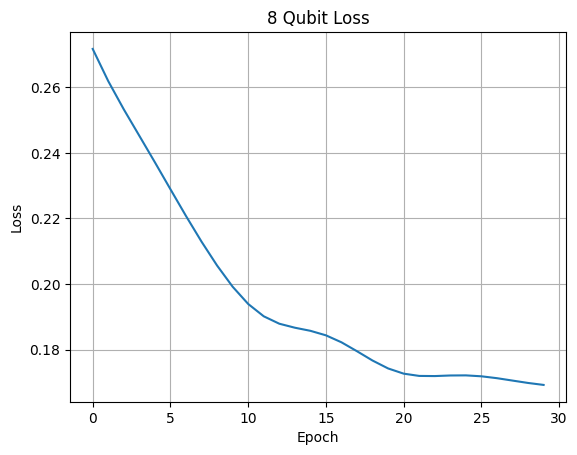

0: ──RY(-1.68)──RY(0.59)──╭●──RY(1.22)────────────╭●─────────RY(-1.26)────────────╭●──────── ···
1: ──RY(-0.47)──RY(1.47)──╰X─╭●─────────RY(-1.69)─╰X────────╭●──────────RY(1.31)──╰X──────── ···
2: ──RY(-0.43)──RY(0.51)─────╰X────────╭●──────────RY(2.02)─╰X─────────╭●──────────RY(-0.02) ···
3: ──RY(-0.47)──RY(-1.28)──────────────╰X─────────╭●─────────RY(-0.15)─╰X─────────╭●──────── ···
4: ──RY(-0.49)──RY(-0.26)─────────────────────────╰X────────╭●──────────RY(-0.91)─╰X──────── ···
5: ──RY(-0.42)──RY(0.46)────────────────────────────────────╰X─────────╭●──────────RY(-0.82) ···
6: ──RY(-0.51)──RY(-1.35)──────────────────────────────────────────────╰X─────────╭●──────── ···
7: ──RY(-0.42)──RY(-1.02)─────────────────────────────────────────────────────────╰X──────── ···

0: ··· ──RY(0.93)────────────╭●─────────────────────────────────────────────────────────┤  <Z>
1: ··· ─╭●──────────RY(0.34)─╰X─────────╭●──────────────────────────────────────────────┤     
2: ··· ─╰X─────────╭●─────────RY(

In [31]:
acc8 = indian_vqc(8)

In [32]:
print(
    "4 Qubit Accuracy:",
    acc4
)

print(
    "6 Qubit Accuracy:",
    acc6
)

print(
    "8 Qubit Accuracy:",
    acc8
)

4 Qubit Accuracy: 0.7222222222222222
6 Qubit Accuracy: 0.7777777777777778
8 Qubit Accuracy: 0.9444444444444444


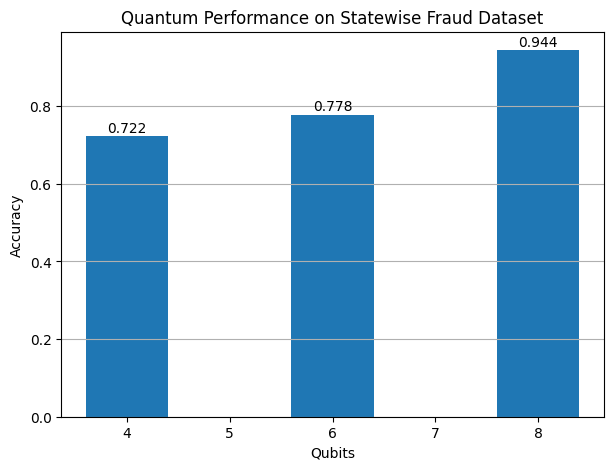

In [33]:
qubits=[4,6,8]

accs=[
    acc4,
    acc6,
    acc8
]

plt.figure(
    figsize=(7,5)
)

plt.bar(
    qubits,
    accs
)

plt.xlabel(
    "Qubits"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
"Quantum Performance on Statewise Fraud Dataset"
)

for i,v in enumerate(accs):

    plt.text(
        qubits[i],
        v+0.01,
        str(
            round(v,3)
        ),
        ha='center'
    )

plt.grid(
    axis='y'
)

plt.show()